# 01_EDA_Final_Notebook.ipynb

## Executive Summary

The Titanic dataset contains passenger info (age, sex, class, fare, etc.) and the target 'survived'.
Key findings:
- Survival rate differs strongly by passenger class and sex.
- Age shows a wide distribution and has missing values; median imputation is used for robustness.
- Feature engineering (family_size, title) creates useful predictors for downstream modeling.

## Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load data

In [16]:
try:
    df = sns.load_dataset('titanic')
except Exception:
# If seaborn dataset not available, user should place titanic.csv in working directory
    df = pd.read_csv('titanic.csv')


print('Shape:', df.shape)
print(df.head())

Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## Initial checks

In [19]:
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())


Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## Missing data rationale & imputation

Rationale:
- 'age' has missing values and influences survival. Age is skewed; median imputation is robust to outliers.
- 'embarked' has few missing values; impute with mode (most common port).
- 'deck' is highly incomplete; drop or encode as 'Unknown'.

### Impute age with median

In [24]:
df['age_imputed'] = df['age'].fillna(df['age'].median())
# Impute embarked with mode
if 'embarked' in df.columns:
    df['embarked_imputed'] = df['embarked'].fillna(df['embarked'].mode().iloc[0])

## Univariate visuals and save PNGs

In [27]:
out_dir = os.getcwd()

#### Age distribution

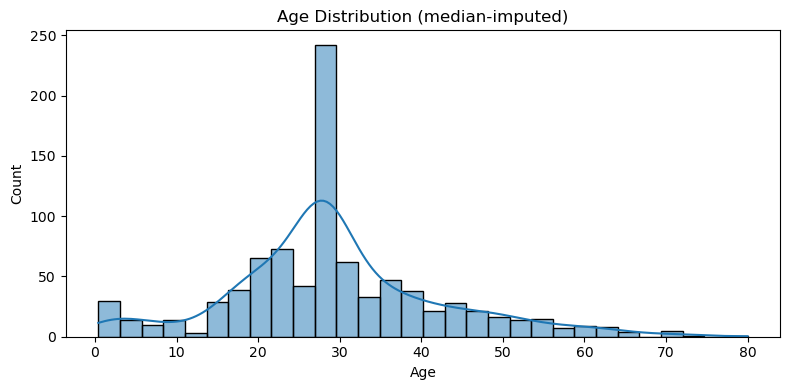

In [30]:
plt.figure(figsize=(8,4))
sns.histplot(df['age_imputed'].dropna(), kde=True)
plt.title('Age Distribution (median-imputed)')
plt.xlabel('Age')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, '01_EDA_age.png'))
plt.show()
plt.close()

#### Survival by class

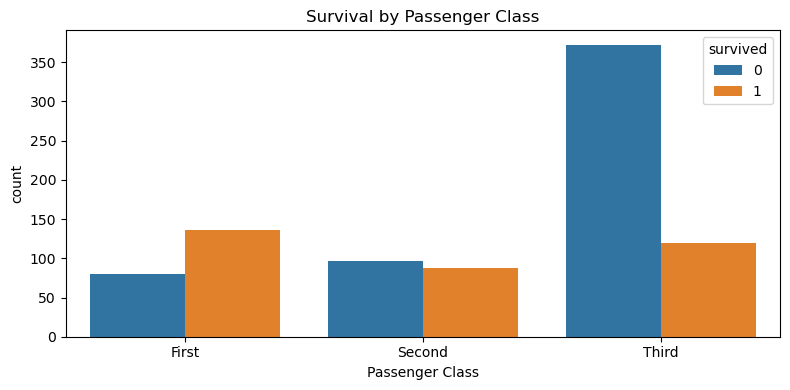

In [37]:
plt.figure(figsize=(8,4))
sns.countplot(x='class', hue='survived', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, '01_EDA_survival_by_class.png'))
plt.show()
plt.close()

#### Correlation heatmap for numeric features

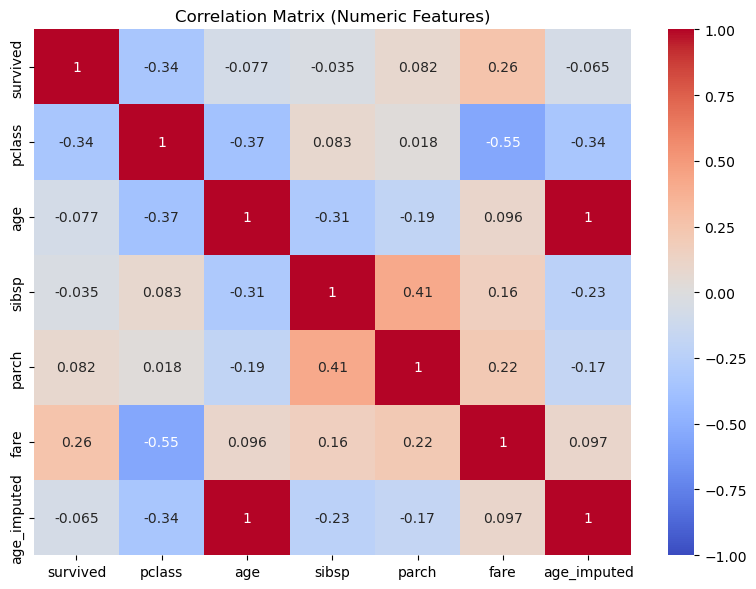

In [40]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, '01_EDA_corr_heatmap.png'))
plt.show()
plt.close()

## Feature engineering

In [43]:
# Family size
if 'sibsp' in df.columns and 'parch' in df.columns:
    df['family_size'] = df['sibsp'] + df['parch']


# Extract title from name if available
if 'name' in df.columns:
    df['title'] = df['name'].str.extract(',\s*([^\.]+)\.')
    df['title'] = df['title'].str.strip()


print('\nEngineered features added: family_size, title (if available)')


Engineered features added: family_size, title (if available)


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Neliswa\AppData\Local\Temp\ipykernel_12420\2037736562.py:8: SyntaxWarning: invalid escape sequence '\s'
  df['title'] = df['name'].str.extract(',\s*([^\.]+)\.')


## Quick bivariate checks

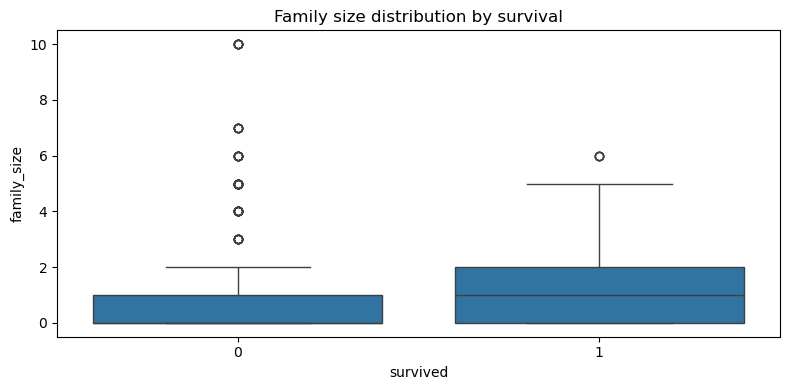

In [46]:
if 'family_size' in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='survived', y='family_size', data=df)
    plt.title('Family size distribution by survival')
    plt.tight_layout()
    plt.show()

## Export cleaned sample and summary

In [51]:
df_sample = df.head(200)
df_sample.to_csv('eda_sample_output.csv', index=False)
summary = df.describe(include='all')
summary.to_csv('eda_summary.csv')
print('\nExported eda_sample_output.csv and eda_summary.csv')


Exported eda_sample_output.csv and eda_summary.csv


## Executive summary

In [55]:
print('- Survival varies strongly by passenger class and sex; these variables are highly predictive.')
print('- Age has missing values; median imputation used to preserve robustness to outliers.')
print('- Engineered features (family_size, title) can add predictive power.')
print('- Next steps: build a baseline classification model (logistic regression), test feature importance, and validate with cross-validation.')

- Survival varies strongly by passenger class and sex; these variables are highly predictive.
- Age has missing values; median imputation used to preserve robustness to outliers.
- Engineered features (family_size, title) can add predictive power.
- Next steps: build a baseline classification model (logistic regression), test feature importance, and validate with cross-validation.
